CIFAR revision

# MP5: Training Your Diffusion Model!

## Setup environment

In [1]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch # added
from torch import optim # added
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR100
from torchvision.transforms import ToTensor
import torchvision.utils as vutils
from torchvision import transforms
import numpy as np

## Visualization helper function

In [2]:
def visualize_images_with_titles(images: torch.Tensor, column_names: list[str], font_size: int):
    """
    Visualize images as a grid and title the columns with the provided names.

    Args:
        images: (N, C, H, W) tensor of images, where N is (number of rows * number of columns)
        column_names: List of column names for the titles.
        font_size: Font size for the titles.

    Example usage:
    visualize_images_with_titles(torch.randn(16, 1, 32, 32), ['1', '2', '3', '4'])
    """
    images = images.detach().cpu().clamp(0., 1.)
    num_images, num_columns = images.shape[0], len(column_names)
    assert num_images % num_columns == 0, 'Number of images must be a multiple of the number of columns.'

    num_rows = num_images // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 2, num_rows * 2))

    for i, ax in enumerate(axes.flat):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        ax.imshow(img)
        ax.axis('off')
        if i < num_columns:
            ax.set_title(column_names[i % num_columns], fontsize=font_size)

    plt.tight_layout()
    plt.show()


def image_add_noise(image: torch.Tensor, sigma: float):
    """
    Add noise to an image.

    Args:
        image: (C, H, W) tensor of image
            Note: ToTensor() will naturally normalize the image to [0, 1]
        sigma: Standard deviation of the Gaussian noise

    Returns:
        Noisy image
    """
    noisy_image = image + torch.randn_like(image) * sigma
    # plt.imshow() will use linear interpolation to map the value of pixel into [0, 1], then map the color
    # noisy_image = noisy_image.clamp(0., 1.)
    return noisy_image.clamp(0.0, 1.0)

# Part 1: Training a Single-step Denoising UNet


## Implementing Simple and Composed Ops

In [3]:
class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.bn(x)
        x = self.gelu(x)
        return x


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.bn(x)
        x = self.gelu(x)
        return x


class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.bn(x)
        x = self.gelu(x)
        return x


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        self.avg_pool = nn.AvgPool2d(kernel_size=8)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.avg_pool(x)
        x = self.gelu(x)
        return x


class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        self.conv = nn.ConvTranspose2d(in_channels, in_channels, kernel_size=8, stride=8, padding=0)
        self.bn = nn.BatchNorm2d(in_channels)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.bn(x)
        x = self.gelu(x)
        return x


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv1 = Conv(in_channels, out_channels)
        self.conv2 = Conv(out_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.conv2(x)
        return x


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.down_conv = DownConv(in_channels, out_channels)
        self.conv_block = ConvBlock(out_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.down_conv(x)
        x = self.conv_block(x)
        return x


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.up_conv = UpConv(in_channels, out_channels)
        self.conv_block = ConvBlock(out_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.up_conv(x)
        x = self.conv_block(x)
        return x

## Implementing Unconditional UNet

In [4]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        self.conv_block1 = ConvBlock(in_channels, num_hiddens)
        self.conv_block2 = ConvBlock(2*num_hiddens, num_hiddens)

        self.down_block1 = DownBlock(num_hiddens, num_hiddens)
        self.down_block2 = DownBlock(num_hiddens, 2*num_hiddens)

        self.flatten = Flatten()

        self.unflatten = Unflatten(2*num_hiddens)

        self.up_block1 = UpBlock(4*num_hiddens, num_hiddens)
        self.up_block2 = UpBlock(2*num_hiddens, num_hiddens)

        self.conv = nn.Conv2d(in_channels=num_hiddens, out_channels=in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # revise for CIFAR
        assert x.shape[-2:] == (32, 32), "Expect input shape to be (32, 32)." # x: N C H W
        # en_%d represents intermediate variables in encoder stage
        en1 = self.conv_block1(x)
        en2 = self.down_block1(en1)
        en3 = self.down_block2(en2)

        flat = self.flatten(en3)

        # de_%d represents intermediate variables in decoder stage
        # cat_%d represent concatenated intermediate variables from both encoder and decoder stages
        de1 = self.unflatten(flat)
        cat1 = torch.cat([de1, en3], dim=1)
        de2 = self.up_block1(cat1)
        cat2 = torch.cat([de2, en2], dim=1)
        de3 = self.up_block2(cat2)
        cat3 = torch.cat([de3, en1], dim=1)

        de4 = self.conv_block2(cat3)

        y = self.conv(de4)
        return y



## Visualizing the noising process

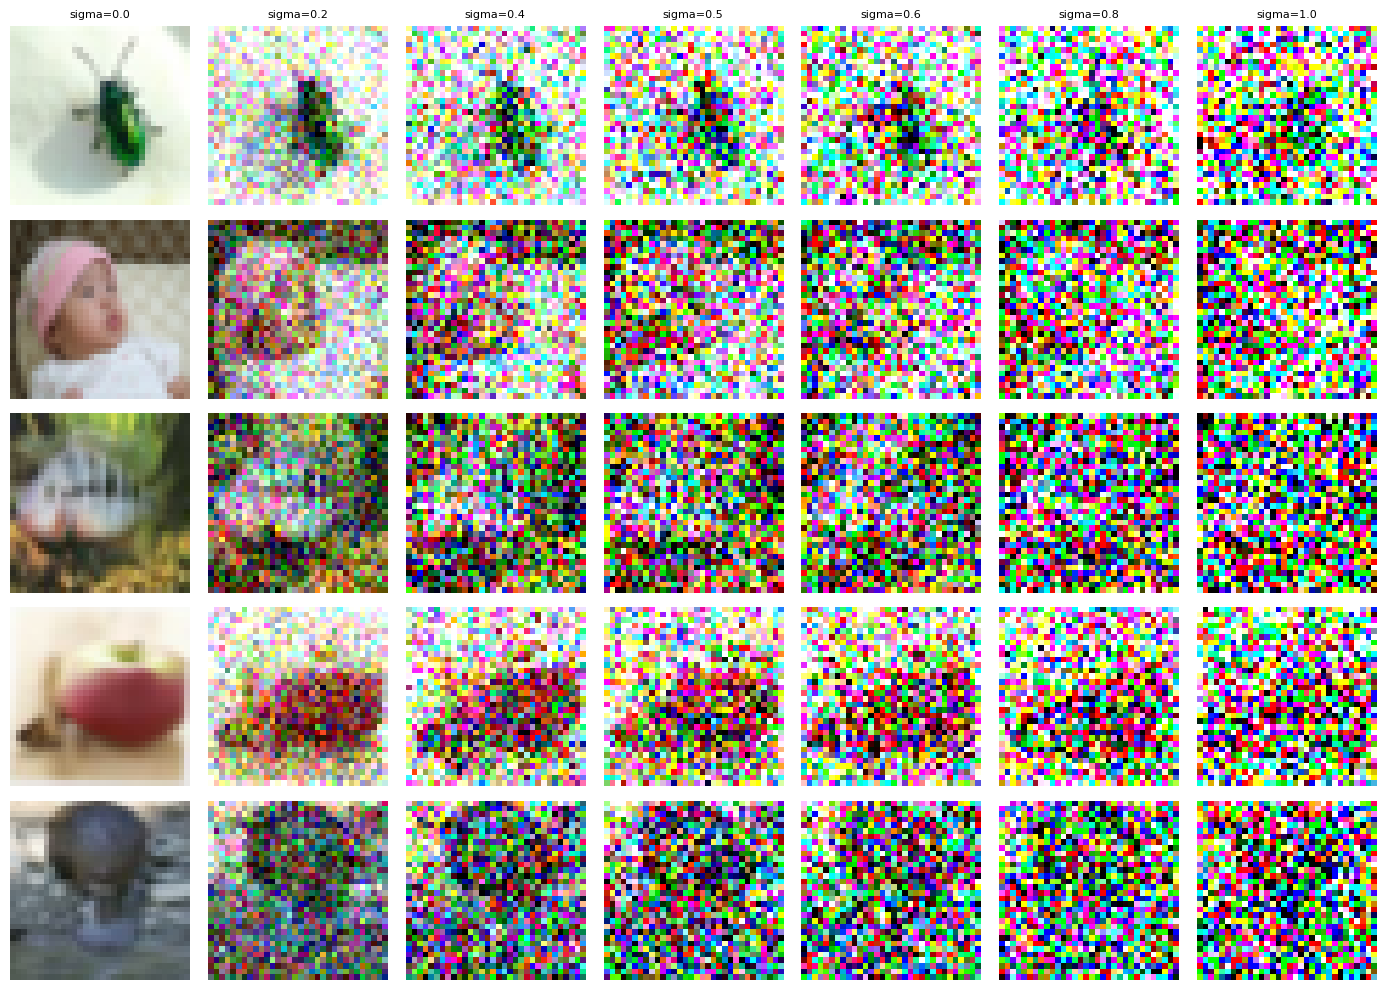

In [5]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5071,0.4867,0.4408), (0.2675,0.2565,0.2761)),
])

dataset = CIFAR100(root="data", download=True, transform=ToTensor(), train=True)

# TODO
target_classes = [7, 2, 1, 0, 4]
samples = []

for num in target_classes:
    idx = next(i for i, (_, label) in enumerate(dataset) if label == num)
    # img is tensor with shape (1, 32, 32)
    img, _ = dataset[idx]
    samples.append(img)

# Visualize difference noising processes
sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

noisy_samples = []
for sample in samples:
    for sigma in sigmas:
        noisy_sample = image_add_noise(sample, sigma)
        noisy_samples.append(noisy_sample)

noisy_samples_tensor = torch.stack(noisy_samples, dim=0)
# print(noisy_samples_tensor.shape)

visualize_images_with_titles(noisy_samples_tensor, [f'sigma={s:.1f}' for s in sigmas], 8)

## Training a Single-Step Unconditional UNet

- Plot the loss curve
- Sample results on the test set

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [7]:
train_dataset = CIFAR100(root='data', download=True, transform=transform, train=True)
train_dataloader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_dataset = CIFAR100(root='data', download=True, transform=transform, train=False)
test_dataloader = DataLoader(test_dataset, batch_size=3, shuffle=False)

# TODO
net = UnconditionalUNet(in_channels=3, num_hiddens=128).to(device)
optimizer = optim.Adam(net.parameters(), lr=1e-4)
criterion = nn.MSELoss()


=== After epoch 1 ===


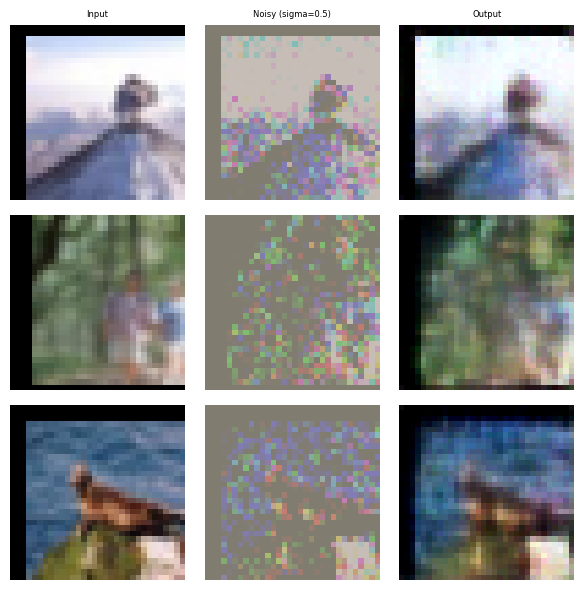


=== After epoch 5 ===


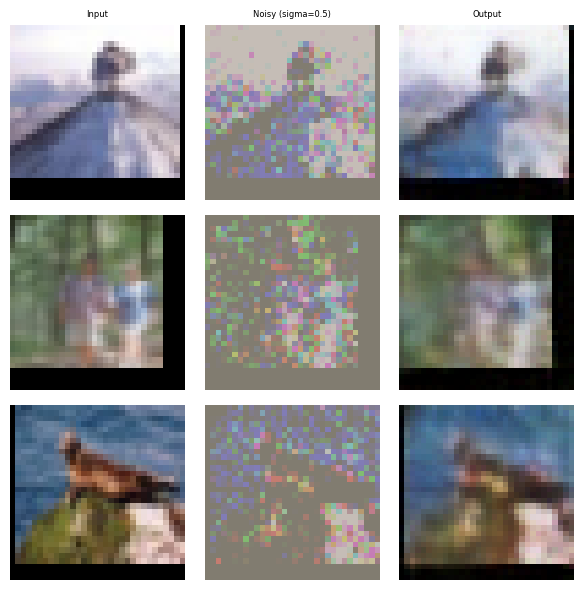

In [8]:
# helper function to get the normal picture
def denormalize(batch: torch.Tensor, mean, std):
    mean = torch.tensor(mean, device=batch.device).view(1, -1, 1, 1)
    std  = torch.tensor(std,  device=batch.device).view(1, -1, 1, 1)
    return batch * std + mean

num_epochs = 5
# Record the losses for each batch/step
step_losses = []

# Training the UNet model
for epoch in range(5):
    net.train()
    for img, _ in train_dataloader:
        img = img.to(device)
        # Add noise to the images with sigma=0.5
        noisy_img = image_add_noise(img, sigma=0.5)

        # Forward pass
        pred = net(noisy_img)
        loss = criterion(pred, img)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        step_losses.append(loss.item())

    # Do visualization on epoch 1 and epoch 5
    if epoch == 0 or epoch == 4:
        net.eval()
        img_test, _ = next(iter(test_dataloader))
        img_test = img_test.to(device)

        # Add noise to the test images
        noisy_img_test = image_add_noise(img_test, sigma=0.5)

        # Forward pass
        with torch.no_grad():
            denoised_img = net(noisy_img_test)

        # Move the images to CPU
        img_test  = denormalize(img_test,mean=(0.5071,0.4867,0.4408), std=(0.2675,0.2565,0.2761)).cpu().clamp(0,1)
        noisy_img_test = denormalize(noisy_img_test,mean=(0.5071,0.4867,0.4408), std=(0.2675,0.2565,0.2761)).cpu().clamp(0,1)
        denoised_img  = denormalize(denoised_img,mean=(0.5071,0.4867,0.4408), std=(0.2675,0.2565,0.2761)).cpu().clamp(0,1)

        # Visualize the origin images, noisy images and denoised images
        img_test_list = []
        for i in range(img_test.shape[0]):
            img_test_list.append(img_test[i])
            img_test_list.append(noisy_img_test[i])
            img_test_list.append(denoised_img[i])
        img_test_tensor = torch.stack(img_test_list, dim=0)

        titles = ['Input', 'Noisy (sigma=0.5)', 'Output']
        print(f"\n=== After epoch {epoch+1} ===")
        visualize_images_with_titles(img_test_tensor, titles, 6)

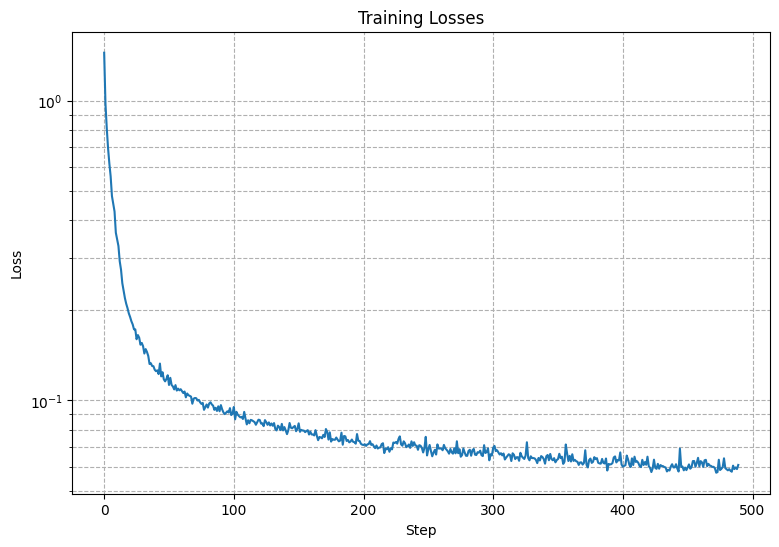

In [9]:
# Plot training loss curves with respect to steps
plt.figure(figsize=(9, 6))
plt.semilogy(step_losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.grid(True, which='both', ls='--')
plt.show()

## Out-of-Distribution Testing

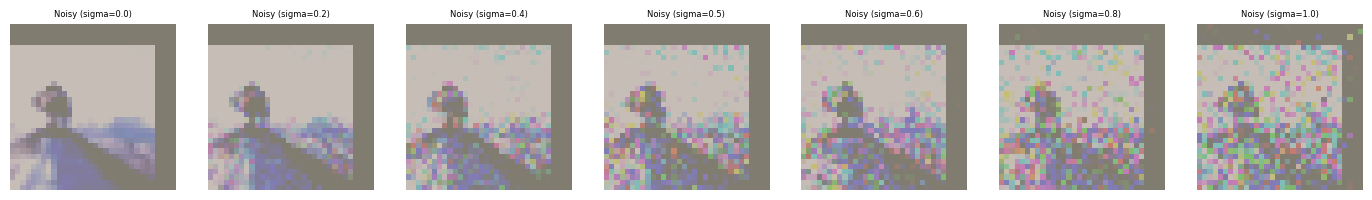

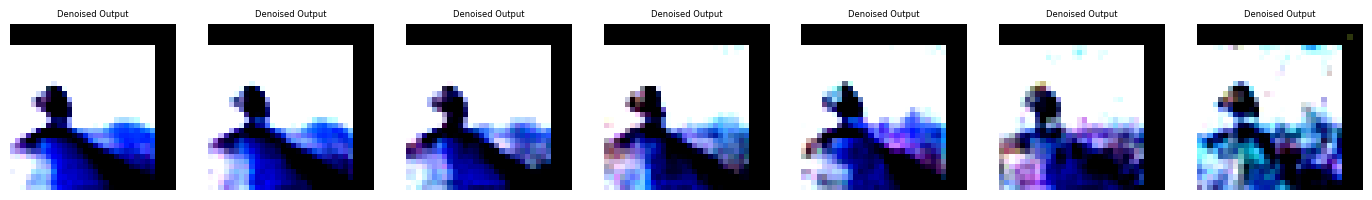

In [10]:
# TODO
# Load the model
net.eval()
net.to(device)

# Load the data
idx = 0
img, _ = test_dataset[idx] # img: (1, 32, 32)
img = img.to(device)

# Visualize difference noising processes
sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

noisy_img_list = []
denoised_img_list = []
with torch.no_grad():
    for sigma in sigmas:
        # Add noise to the images
        noisy_img = image_add_noise(img, sigma)
        noisy_img = noisy_img.unsqueeze(0) # noisy_img: (1, 1, 32, 32)
        # Denoise the images
        denoised_img = net(noisy_img) # denoised_img: (1, 1, 32, 32)

        # Drop the first dimension, and save the images into lists
        noisy_img_list.append(noisy_img.cpu().squeeze(0))
        denoised_img_list.append(denoised_img.cpu().squeeze(0))

# Turn the list into tensors
noisy_img_tensor = torch.stack(noisy_img_list, dim=0)
denoised_img_tensor = torch.stack(denoised_img_list, dim=0)

noisy_img_tensor = denormalize(noisy_img_tensor,mean=(0.5071,0.4867,0.4408), std=(0.2675,0.2565,0.2761)).clamp(0,1)
denoised_img = denormalize(denoised_img_tensor,mean=(0.5071,0.4867,0.4408), std=(0.2675,0.2565,0.2761)).clamp(0,1)

# Visualize the noisy and denoised images
first_column_names = [f'Noisy (sigma={s:.1f})' for s in sigmas]
visualize_images_with_titles(noisy_img_tensor, first_column_names, 6)

second_column_names = ['Denoised Output' for _ in range(len(sigmas))]
visualize_images_with_titles(denoised_img_tensor, second_column_names, 6)

# Part 2: Training a Diffusion Model

### Helper function for generating .gif images

In [11]:
import torch
import numpy as np
import torchvision.utils as vutils
from PIL import Image

# def save_ddpm_gif(
#     caches: torch.Tensor,
#     gif_path: str,
#     ncol: int = 4,
#     nrow: int = 10,
#     duration: int = 100
# ):
#     """
#     Save a DDPM denoising trajectory as a grayscale GIF, arranging each timestep into a grid.
#     """
#     N, T1, C, H, W = caches.shape
#     assert C == 1, "Only single-channel (grayscale) supported."

#     frames = []
#     for t in range(T1):
#         # build the grid exactly as for static x_0 visualization
#         big_grid = vutils.make_grid(caches[:, t], nrow=nrow, padding=0, normalize=False)

#         # clamp pixel values to [0,1]
#         big_grid = big_grid.clamp(0, 1) # (3, ncol*H, nrow*W)

#         # convert the first channel to a uint8 numpy array in [0,255]
#         arr = (big_grid[0].cpu().numpy() * 255).astype(np.uint8)

#         # create a PIL grayscale image from the array
#         img = Image.fromarray(arr, mode='L')
#         frames.append(img)

#     # prepend the cleanest frame, it becomes the static preview:
#     clean_frame = frames[-1]
#     frames.insert(0, clean_frame)

#     # save the sequence of frames as an animated GIF
#     frames[0].save(
#         gif_path,
#         save_all=True,
#         append_images=frames[1:],
#         duration=duration,
#         loop=0
#     )


## Implementing a Time-conditioned UNet

In [12]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.fc1 = nn.Linear(in_channels, out_channels)
        self.gelu = nn.GELU()
        self.fc2 = nn.Linear(out_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.fc2(x)
        return x

class TimeConditionalUNet(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, num_hiddens: int):
        super().__init__()
        self.conv_block1 = ConvBlock(in_channels, num_hiddens)
        self.conv_block2 = ConvBlock(2*num_hiddens, num_hiddens)

        self.down_block1 = DownBlock(num_hiddens, num_hiddens)
        self.down_block2 = DownBlock(num_hiddens, 2*num_hiddens)

        self.flatten = Flatten()

        self.unflatten = Unflatten(2*num_hiddens)

        self.up_block1 = UpBlock(4*num_hiddens, num_hiddens)
        self.up_block2 = UpBlock(2*num_hiddens, num_hiddens)

        self.fcblock1 = FCBlock(1, 2*num_hiddens)
        self.fcblock2 = FCBlock(1, num_hiddens)

        self.conv = nn.Conv2d(in_channels=num_hiddens, out_channels=in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (32, 32), "Expect input shape to be (28, 28)."
        # en_%d represents intermediate variables in encoder stage
        en1 = self.conv_block1(x)
        en2 = self.down_block1(en1)
        en3 = self.down_block2(en2)

        flat = self.flatten(en3)

        # de_%d represents intermediate variables in decoder stage
        # add_%d represents the time conditioning signal embedded in decoder stage
        # cat_%d represent concatenated intermediate variables from both encoder and decoder stages
        de1 = self.unflatten(flat)
        # Transform t into form of (N, 1) because nn.Linear accepts 2D input
        # If accept 1D input, it will broadcast to (1, N)
        add1 = self.fcblock1(t.unsqueeze(-1)).reshape(t.shape[0], -1, 1, 1) # (N, 2D, 1, 1)
        de1 = de1 + add1
        cat1 = torch.cat([de1, en3], dim=1)

        de2 = self.up_block1(cat1)
        add2 = self.fcblock2(t.unsqueeze(-1)).reshape(t.shape[0], -1, 1, 1) # (N, D, 1, 1)
        de2= de2 + add2
        cat2 = torch.cat([de2, en2], dim=1)

        de3 = self.up_block2(cat2)
        cat3 = torch.cat([de3, en1], dim=1)

        de4 = self.conv_block2(cat3)

        y = self.conv(de4)
        return y


## Implementing DDPM Forward and Inverse Process for Time-conditioned Denoising

In [13]:
def ddpm_schedule(beta1: float, beta2: float, num_ts: int) -> dict:
    """Constants for DDPM training and sampling.

    Arguments:
        beta1: float, starting beta value.
        beta2: float, ending beta value.
        num_ts: int, number of timesteps.

    Returns:
        dict with keys:
            betas: linear schedule of betas from beta1 to beta2.
            alphas: 1 - betas.
            alpha_bars: cumulative product of alphas.
    """
    assert beta1 < beta2 < 1.0, "Expect beta1 < beta2 < 1.0."
    # Note that t is from 0 to num_ts(T)
    beta_tensor = torch.linspace(beta1, beta2, steps=num_ts+1) # beta_tensor: (num_ts+1,)
    alpha_tensor = 1 - beta_tensor # alpha_tensor: (num_ts+1,)
    # alpha_bar is the cumulative product of alphas
    alpha_bar_tensor = torch.cumprod(alpha_tensor, dim=0) # alpha_bar_tensor: (num_ts+1,)

    # Return the dict with keys
    result_dict = {}
    result_dict["betas"] = beta_tensor
    result_dict["alphas"] = alpha_tensor
    result_dict["alpha_bars"] = alpha_bar_tensor

    return result_dict


In [14]:
def ddpm_forward(
    unet: TimeConditionalUNet,
    ddpm_schedule: dict,
    x_0: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1 of the DDPM paper.

    Args:
        unet: TimeConditionalUNet
        ddpm_schedule: dict
        x_0: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) diffusion loss.
    """
    unet.train()
    # YOUR CODE HERE.
    N = x_0.shape[0]

    # Generate time steps randomly, and normalize to [0, 1]
    # Note in the algorithm, the random time steps are from 1 to num_ts(T)
    t = torch.randint(1, num_ts+1, (N,), device=x_0.device, dtype=torch.long)
    t_norm = t / num_ts

    # Generate gaussian noise
    eps = torch.randn_like(x_0)

    # Generate x_t with alpha_bar
    # The shape of t is (N,), so the shape of alpha_bar is (N, )
    alpha_bar = ddpm_schedule['alpha_bars'][t]
    alpha_bar = alpha_bar.reshape(N, 1, 1, 1) # alpha_bar: (N, 1, 1, 1)
    x_t = torch.sqrt(alpha_bar)*x_0 + torch.sqrt(1. - alpha_bar)*eps

    # Let UNet predict the noise
    pred_eps = unet(x_t, t_norm)

    # Calculate diffusion loss
    diffuse_loss = F.mse_loss(pred_eps, eps, reduction="mean")
    return diffuse_loss


In [15]:
@torch.inference_mode()
def ddpm_sample(
    unet: TimeConditionalUNet,
    ddpm_schedule: dict,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2 of the DDPM paper with classifier-free guidance.

    Args:
        unet: TimeConditionalUNet
        ddpm_schedule: dict
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches
        -> We have N=1 in this case.
    """
    unet.eval()
    # YOUR CODE HERE.
    H, W = img_wh
    C = 3 # The number of image channels in MINST is 1
    # Get device of UNet
    unet_device = next(unet.parameters()).device

    # Get tensors in ddpm_schedule
    beta = ddpm_schedule['betas']
    alpha = ddpm_schedule['alphas']
    alpha_bar = ddpm_schedule['alpha_bars']

    # Generate x_t(t=T) as pure noise
    torch.manual_seed(seed)
    x_t = torch.randn(1, C, H, W, device = unet_device) # x_T: (1, C, H, W)
    x_t = x_t.to(unet_device)
    caches = [x_t.clone()]

    # Stepwise backsampling from t=num_ts(T) to t=1
    for t in range(num_ts, 0, -1):
        t_norm = torch.tensor([t], device=unet_device, dtype=torch.float32) / num_ts
        # Predict noise
        pred_eps = unet(x_t, t_norm)

        # Get beta_t/alpha_t/alpha_bar_t
        beta_t = beta[t]
        alpha_t = alpha[t]
        alpha_bar_t = alpha_bar[t]

        # Generate noise z
        if t > 1:
            z = torch.randn_like(x_t) # z: (1, C, H, W)
        else:
            z = torch.zeros_like(x_t) # z: (1, C, H, W)

        # According to the formula: x_{t-1} = 1/√α_t [ x_t - (1-α_t)/√(1-ᾱ_t)·pred_eps ] + √β_t·z
        coef_of_pred_eps = (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)
        x_t = (x_t - coef_of_pred_eps * pred_eps) / torch.sqrt(alpha_t) + torch.sqrt(beta_t) * z

        # Add result into the cache list
        if t % 10 == 0:
            caches.append(x_t)

    caches_tensor = torch.stack(caches, dim=0) # (T_animation, 1, C, H, W)
    caches_tensor = caches_tensor.permute(1, 0, 2, 3, 4) # (1, T_animation, C, H, W)

    return x_t, caches_tensor


In [16]:
class DDPM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        betas: tuple[float, float] = (1e-4, 0.02),
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

        # Note we register alphas/alpha_bars/betas as nn.ParameterDict, they will be optimized during training;
        # (1) We can change to store them as buffer:
        # sched = ddpm_schedule(beta1, beta2, num_ts)
        # self.register_buffer('betas', sched['betas'])
        # self.register_buffer('alphas', sched['alphas'])
        # self.register_buffer('alpha_bars', sched['alpha_bars'])
        #
        # (2) We can calculate them locally in forward() and sample()...
        #
        # (3) Only include parameters in unet when setting Adam optimizer...
        self.ddpm_schedule = nn.ParameterDict(ddpm_schedule(betas[0], betas[1], num_ts))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return ddpm_forward(self.unet, self.ddpm_schedule, x, self.num_ts)

    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return ddpm_sample(self.unet, self.ddpm_schedule, img_wh, self.num_ts, seed)

## Training the Time-conditioned UNet

- Plot the loss curve
- Sample results on the test set

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [18]:
train_dataset = CIFAR100(root='data', download=True, transform=transform, train=True)
train_dataloader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_dataset = CIFAR100(root='data', download=True, transform=transform, train=False)
test_dataloader = DataLoader(test_dataset, batch_size=40, shuffle=True)

# TODO
net = TimeConditionalUNet(in_channels=3, num_classes=0, num_hiddens=64).to(device)
model = DDPM(net, betas=(0.0001, 0.02), num_ts=300, p_uncond=0.0).to(device)

# Determine loss funtion, shceduler and optimizer
from torch.optim.lr_scheduler import ExponentialLR

num_epochs = 20
learning_rate = 1e-3
gamma = 0.1 ** (1/num_epochs)

optimizer = optim.Adam(model.unet.parameters(), lr=learning_rate)
scheduler = ExponentialLR(optimizer, gamma=gamma)
# criterion = nn.MSELoss()

Epoch  1 | avg train loss: 2.6125e-01


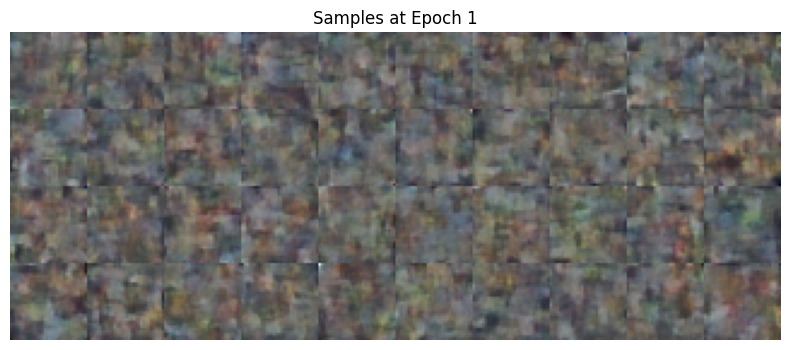

Epoch  2 | avg train loss: 1.5208e-01
Epoch  3 | avg train loss: 1.4082e-01
Epoch  4 | avg train loss: 1.2946e-01
Epoch  5 | avg train loss: 1.2320e-01


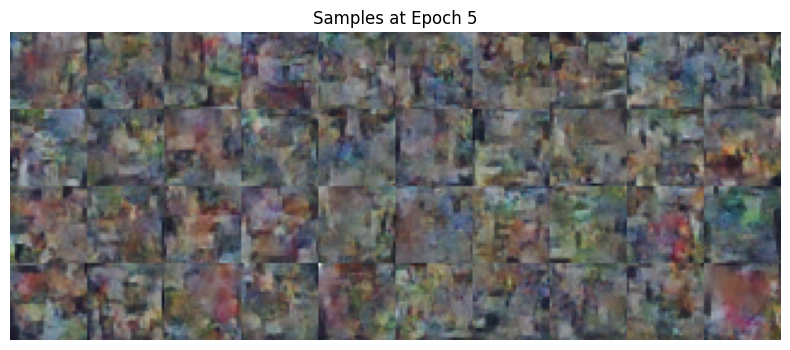

Epoch  6 | avg train loss: 1.2060e-01
Epoch  7 | avg train loss: 1.1859e-01
Epoch  8 | avg train loss: 1.1596e-01
Epoch  9 | avg train loss: 1.1318e-01
Epoch 10 | avg train loss: 1.1261e-01


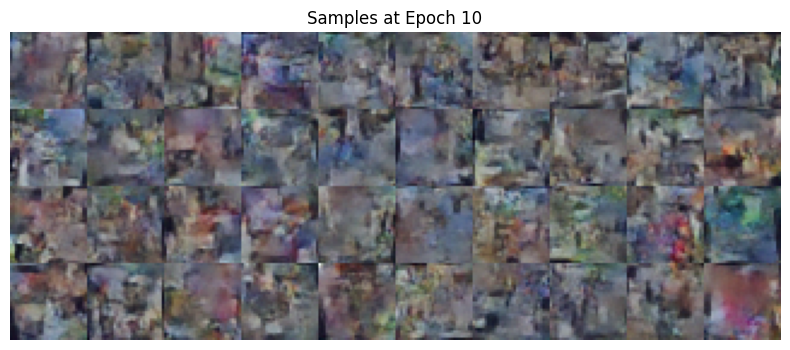

Epoch 11 | avg train loss: 1.1104e-01
Epoch 12 | avg train loss: 1.1060e-01
Epoch 13 | avg train loss: 1.0899e-01
Epoch 14 | avg train loss: 1.0754e-01
Epoch 15 | avg train loss: 1.0762e-01


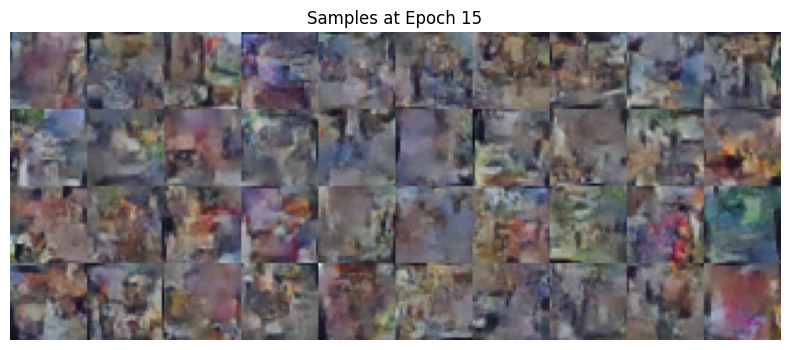

Epoch 16 | avg train loss: 1.0673e-01
Epoch 17 | avg train loss: 1.0691e-01
Epoch 18 | avg train loss: 1.0572e-01
Epoch 19 | avg train loss: 1.0464e-01
Epoch 20 | avg train loss: 1.0488e-01


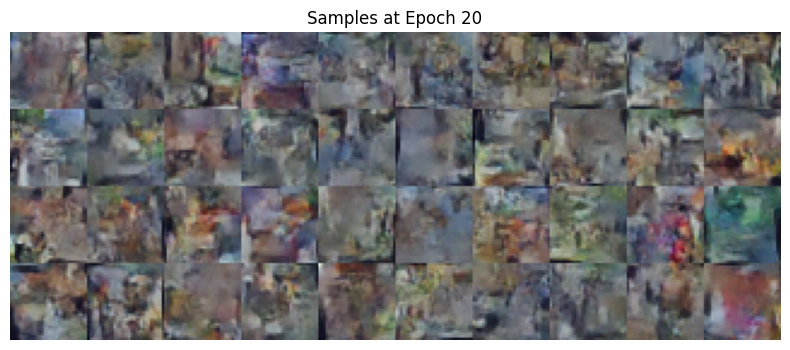

In [19]:
# Record the losses for each batch/step
step_losses=[]
checkpoints = {0, 4, 9, 14, 19}

# Train the diffusion model
for epoch in range(0, num_epochs):
    model.train()

    for x_0, _ in train_dataloader:
        x_0 = x_0.to(device)

        # Forward pass
        # Note that DDPM forward() returns the diffusion loss
        loss = model(x_0)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        step_losses.append(loss.item())

    # Update the learning rate
    scheduler.step()

    # Calculate the average loss over the current epoch
    avg_loss = sum(step_losses[-len(train_dataloader):]) / len(train_dataloader)
    print(f"Epoch {epoch+1:2d} | avg train loss: {avg_loss:.4e}")

    # Visualize on certain epochs
    if epoch in checkpoints:
        model.eval()
        n_rows, n_cols = 4, 10
        num_samples = n_rows * n_cols
        samples = []
        caches = []
        for seed in range(num_samples):
            img, cache = model.sample(img_wh=(32,32), seed=seed) # img: (1, 1, 32, 32) cache: (1, 301, 1, 28, 28)
            samples.append(img.cpu().squeeze(0)) # (1, 28, 28)
            caches.append(cache.cpu().squeeze(0)) # (301, 1, 28, 28)
        grid = torch.stack(samples, dim=0) # (40, 1, 28, 28)
        cache_grid = torch.stack(caches, dim=0) # (40, 301, 1, 28, 28)

        # save_ddpm_gif(cache_grid, f"gif/Time_UNet_epoch_{epoch+1}.gif", n_rows, n_cols, 10)

        big_grid = vutils.make_grid(grid, nrow=n_cols, padding=0, normalize=True)  # big_grid: (3, 4*28, 10*28)
        # print(big_grid.shape)

        plt.figure(figsize=(10, 4))
        img_grid = big_grid.permute(1, 2, 0).cpu().numpy()
        plt.imshow(img_grid)
        plt.axis('off')
        plt.title(f"Samples at Epoch {epoch+1}")
        plt.show()

        # fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows))
        # for i, ax in enumerate(axes.flat):
        #     ax.imshow(grid[i], cmap='gray')
        #     ax.axis('off')
        # plt.suptitle(f"Samples at Epoch {epoch+1}")
        # plt.tight_layout()
        # plt.show()


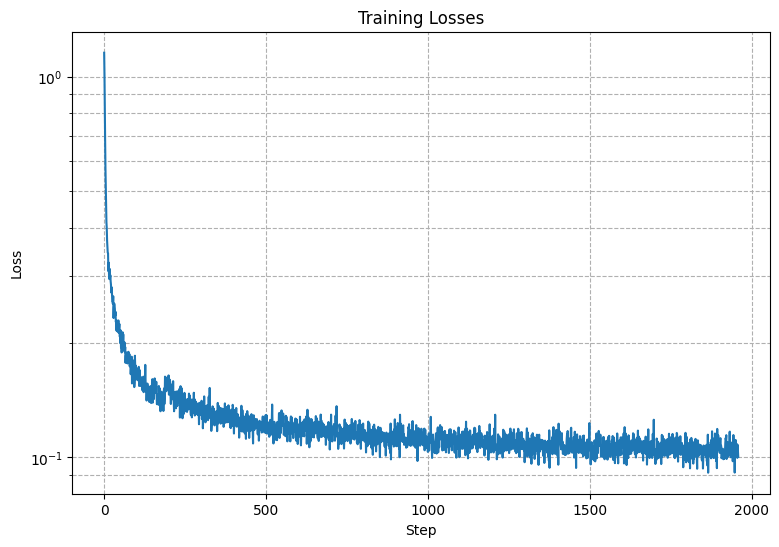

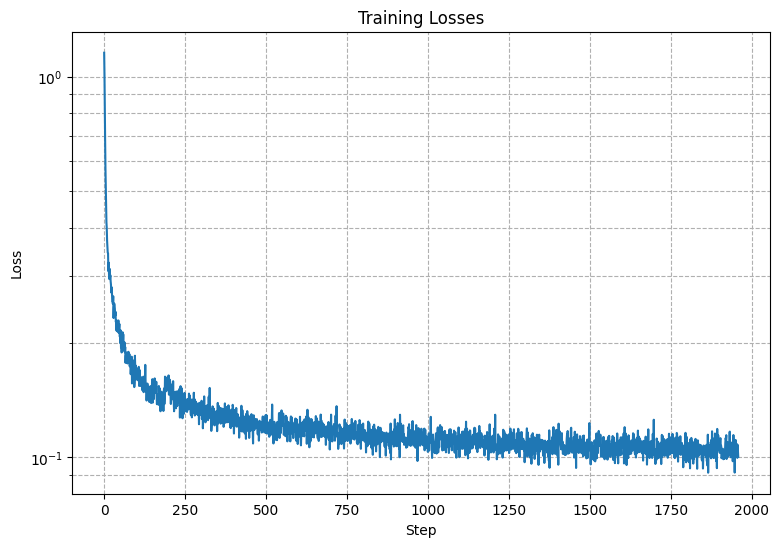

In [20]:
# Plot training loss curves with respect to first 4000 steps
plt.figure(figsize=(9, 6))
plt.semilogy(step_losses[:4000])
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.grid(True, which='both', ls='--')
# Only choose 5 ticks(0, 1000, 2000, 3000, 4000) in the x-axis
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True))
plt.show()


# Plot training loss curves with respect to all steps
plt.figure(figsize=(9, 6))
plt.semilogy(step_losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.grid(True, which='both', ls='--')
plt.show()

## Implementing class-conditioned UNet

In [21]:
class ClassConditionalUNet(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, num_hiddens: int):
        super().__init__()
        self.conv_block1 = ConvBlock(in_channels, num_hiddens)
        self.conv_block2 = ConvBlock(2*num_hiddens, num_hiddens)

        self.down_block1 = DownBlock(num_hiddens, num_hiddens)
        self.down_block2 = DownBlock(num_hiddens, 2*num_hiddens)

        self.flatten = Flatten()

        self.unflatten = Unflatten(2*num_hiddens)

        self.up_block1 = UpBlock(4*num_hiddens, num_hiddens)
        self.up_block2 = UpBlock(2*num_hiddens, num_hiddens)

        # Time-embedding FCBlocks
        self.fcblock1 = FCBlock(1, 2*num_hiddens)
        self.fcblock2 = FCBlock(1, num_hiddens)

        # Class-embedding FCBlocks
        self.fcblock3 = FCBlock(num_classes, 2*num_hiddens)
        self.fcblock4 = FCBlock(num_classes, num_hiddens)

        self.conv = nn.Conv2d(in_channels=num_hiddens, out_channels=in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x: torch.Tensor, c: torch.Tensor, t: torch.Tensor, mask: torch.Tensor | None = None) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (32, 32), "Expect input shape to be (28, 28)."
        # First encode c into one-hot vector
        num_classes = self.fcblock3.fc1.in_features
        c_oh = F.one_hot(c, num_classes).float() # (N, 10)
        # Mask out condition when mask == 0
        if mask is None:
            mask = torch.ones_like(c, dtype=c_oh.dtype) # (N, )
        c_oh = c_oh * mask.unsqueeze(-1)


        # en_%d represents intermediate variables in encoder stage
        en1 = self.conv_block1(x)
        en2 = self.down_block1(en1)
        en3 = self.down_block2(en2)

        flat = self.flatten(en3)

        # de_%d represents intermediate variables in decoder stage
        # add_%d represents the time conditioning signal embedded in decoder stage
        # cat_%d represent concatenated intermediate variables from both encoder and decoder stages
        de1 = self.unflatten(flat)
        add1 = self.fcblock1(t.unsqueeze(-1)).reshape(t.shape[0], -1, 1, 1) # (N, 2D, 1, 1)
        add3 = self.fcblock3(c_oh).reshape(c_oh.shape[0], -1, 1, 1) # (N, 2D, 1, 1)
        de1 = de1 + add1 + add3
        cat1 = torch.cat([de1, en3], dim=1)

        de2 = self.up_block1(cat1)
        add2 = self.fcblock2(t.unsqueeze(-1)).reshape(t.shape[0], -1, 1, 1) # (N, D, 1, 1)
        add4 = self.fcblock4(c_oh).reshape(c_oh.shape[0], -1, 1, 1) # (N, D, 1, 1)
        de2= de2 + add2 + add4
        cat2 = torch.cat([de2, en2], dim=1)

        de3 = self.up_block2(cat2)
        cat3 = torch.cat([de3, en1], dim=1)

        de4 = self.conv_block2(cat3)

        y = self.conv(de4)
        return y

In [22]:
def ddpm_forward(
    unet: ClassConditionalUNet,
    ddpm_schedule: dict,
    x_0: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 3 of the DDPM paper.

    Args:
        unet: ClassConditionalUNet
        ddpm_schedule: dict
        x_0: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) diffusion loss.
    """
    unet.train()
    # YOUR CODE HERE.
    N = x_0.shape[0]

    # Generate time steps randomly, and normalize to [0, 1]
    # Note in the algorithm, the random time steps are from 1 to num_ts(T)
    t = torch.randint(1, num_ts+1, (N,), device=x_0.device, dtype=torch.long)
    t_norm = t / num_ts

    # Generate gaussian noise
    eps = torch.randn_like(x_0)

    # Generate x_t with alpha_bar
    # The shape of t is (N,), so the shape of alpha_bar is (N, )
    alpha_bar = ddpm_schedule['alpha_bars'][t]
    alpha_bar = alpha_bar.reshape(N, 1, 1, 1) # alpha_bar: (N, 1, 1, 1)
    x_t = torch.sqrt(alpha_bar)*x_0 + torch.sqrt(1. - alpha_bar)*eps

    # Make dropout mask for classifier-free guidance
    mask = torch.rand(N, device=x_0.device)
    mask = (mask > p_uncond).float()

    # Let UNet predict the noise
    pred_eps = unet(x_t, c, t_norm, mask)

    # Calculate diffusion loss
    diffuse_loss = F.mse_loss(pred_eps, eps, reduction="mean")
    return diffuse_loss


In [23]:
@torch.inference_mode()
def ddpm_sample(
    unet: ClassConditionalUNet,
    ddpm_schedule: dict,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 4 of the DDPM paper with classifier-free guidance.

    Args:
        unet: ClassConditionalUNet
        ddpm_schedule: dict
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()
    # YOUR CODE HERE.
    H, W = img_wh
    N = c.shape[0]
    C = 3 # The number of image channels in MINST is 1

    # Get device of UNet
    unet_device = next(unet.parameters()).device

    # Get tensors in ddpm_schedule
    beta = ddpm_schedule['betas']
    alpha = ddpm_schedule['alphas']
    alpha_bar = ddpm_schedule['alpha_bars']

    # Generate x_t(t=T) as pure noise
    torch.manual_seed(seed)
    x_t = torch.randn(N, C, H, W) # x_T: (N, C, H, W)
    x_t = x_t.to(unet_device)
    # Cache list
    caches = [x_t.clone()]

    # Stepwise backsampling from t=num_ts(T) to t=1
    for t in range(num_ts, 0, -1):
        t_norm = torch.tensor([t], device=unet_device, dtype=torch.float32) / num_ts
        t_norm = t_norm.repeat(N)

        # Classifier-free guidance
        mask_u = torch.zeros(N, device=unet_device)
        mask_c = torch.ones(N, device=unet_device)
        pred_eps_u = unet(x_t, c, t_norm, mask_u)
        pred_eps_c = unet(x_t, c, t_norm, mask_c)
        pred_eps = pred_eps_u + guidance_scale * (pred_eps_c - pred_eps_u)

        # Get beta_t/alpha_t/alpha_bar_t
        beta_t = beta[t]
        alpha_t = alpha[t]
        alpha_bar_t = alpha_bar[t]

        # Generate noise z
        if t > 1:
            z = torch.randn_like(x_t) # z: (N, C, H, W)
        else:
            z = torch.zeros_like(x_t) # z: (N, C, H, W)

        # According to the formula: x_{t-1} = 1/√α_t [ x_t - (1-α_t)/√(1-ᾱ_t)·pred_eps ] + √β_t·z
        coef_of_pred_eps = (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)
        x_t = (x_t - coef_of_pred_eps * pred_eps) / torch.sqrt(alpha_t) + torch.sqrt(beta_t) * z

        # Add result into the cache list
        if t % 10 == 0:
            caches.append(x_t)

    caches_tensor = torch.stack(caches, dim=0) # (T_animation, N, C, H, W)
    caches_tensor = caches_tensor.permute(1, 0, 2, 3, 4) # (N, T_animation, C, H, W)

    return x_t, caches_tensor

In [24]:
class DDPM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        betas: tuple[float, float] = (1e-4, 0.02),
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.betas = betas
        self.num_ts = num_ts
        self.p_uncond = p_uncond
        self.ddpm_schedule = nn.ParameterDict(ddpm_schedule(betas[0], betas[1], num_ts))

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) diffusion loss.
        """
        return ddpm_forward(self.unet, self.ddpm_schedule, x, c, self.p_uncond, self.num_ts)

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return ddpm_sample(self.unet, self.ddpm_schedule, c, img_wh, self.num_ts, guidance_scale, seed)


## Training the Class-conditioned UNet

- Plot the loss curve
- Sample results on the test set

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [26]:
train_dataset = CIFAR100(root='data', download=True, transform=ToTensor(), train=True)
train_dataloader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_dataset = CIFAR100(root='data', download=True, transform=ToTensor(), train=False)
test_dataloader = DataLoader(test_dataset, batch_size=40, shuffle=True)

# TODO
net = ClassConditionalUNet(in_channels=3, num_classes=100, num_hiddens=64)
model = DDPM(net, betas=(0.0001, 0.02), num_ts=300, p_uncond=0.1).to(device)

# Determine loss funtion, shceduler and optimizer
from torch.optim.lr_scheduler import ExponentialLR

num_epochs = 20
learning_rate = 1e-3
gamma = 0.1 ** (1/num_epochs)

optimizer = optim.Adam(model.unet.parameters(), lr=learning_rate)
scheduler = ExponentialLR(optimizer, gamma=gamma)
# criterion = nn.MSELoss()

Epoch  1 | avg train loss: 1.6115e-01


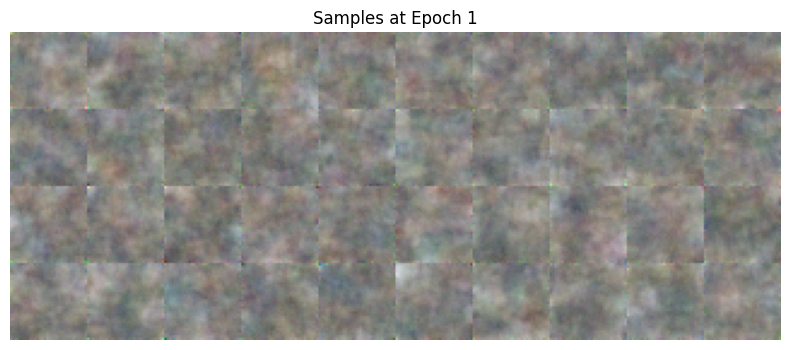

Epoch  2 | avg train loss: 7.2019e-02
Epoch  3 | avg train loss: 6.4113e-02
Epoch  4 | avg train loss: 5.8900e-02
Epoch  5 | avg train loss: 5.5110e-02


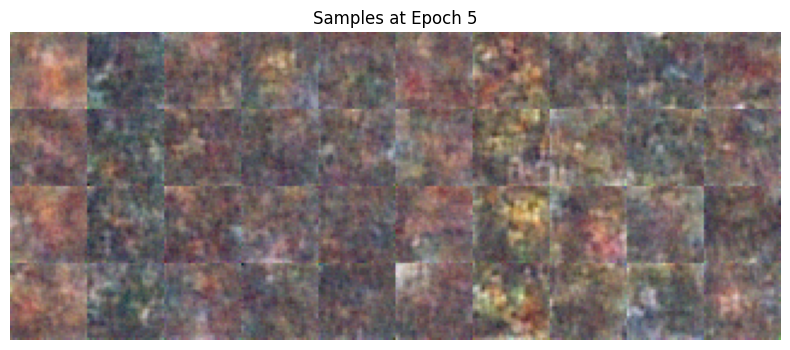

Epoch  6 | avg train loss: 5.3027e-02
Epoch  7 | avg train loss: 5.1235e-02
Epoch  8 | avg train loss: 4.9975e-02
Epoch  9 | avg train loss: 4.8267e-02
Epoch 10 | avg train loss: 4.7249e-02


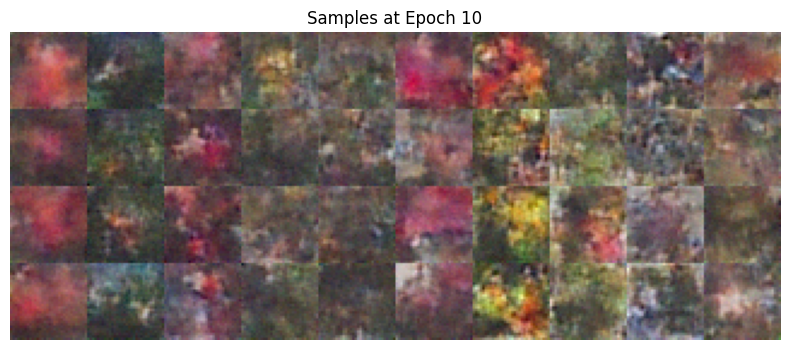

Epoch 11 | avg train loss: 4.6828e-02
Epoch 12 | avg train loss: 4.6410e-02
Epoch 13 | avg train loss: 4.5890e-02
Epoch 14 | avg train loss: 4.4831e-02
Epoch 15 | avg train loss: 4.4182e-02


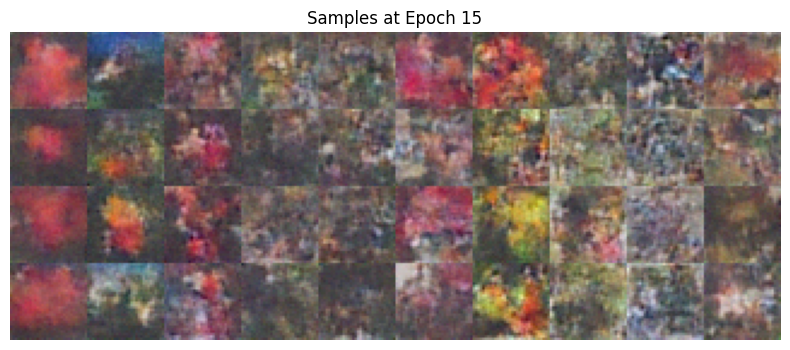

Epoch 16 | avg train loss: 4.4164e-02
Epoch 17 | avg train loss: 4.4201e-02
Epoch 18 | avg train loss: 4.3882e-02
Epoch 19 | avg train loss: 4.3135e-02
Epoch 20 | avg train loss: 4.2640e-02


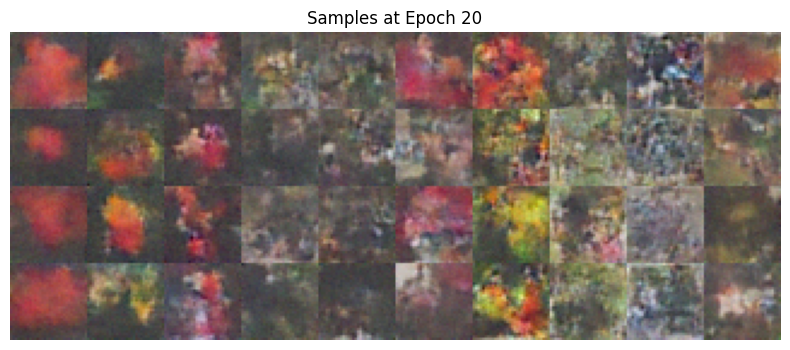

In [27]:
# Record the losses for each batch/step
step_losses=[]
checkpoints = {0, 4, 9, 14, 19}

# Train the diffusion model
for epoch in range(0, num_epochs):
    model.train()

    for x_0, c in train_dataloader:
        x_0 = x_0.to(device)
        c = c.to(device)

        # Forward pass
        # Note that DDPM forward() returns the diffusion loss
        loss = model(x_0, c)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        step_losses.append(loss.item())

    # Update the learning rate
    scheduler.step()

    # Calculate the average loss over the current epoch
    avg_loss = sum(step_losses[-len(train_dataloader):]) / len(train_dataloader)
    print(f"Epoch {epoch+1:2d} | avg train loss: {avg_loss:.4e}")

    # Visualize on certain epochs
    if epoch in checkpoints:
        model.eval()
        n_rows, n_cols = 4, 10
        num_samples = n_rows * n_cols

        # Construct class labels tensor
        c = torch.arange(n_cols, device=device).repeat(n_rows)

        # Set guidance_scale to be 5.0, and we use 42 as a fixed seed
        samples, caches = model.sample(c, (32, 32), 5.0, seed=42) # samples: (40, 1, 28, 28) caches: (40, 301, 1, 28, 28)

        # save_ddpm_gif(caches, f"gif/Class_Unet_epoch_{epoch+1}.gif", n_rows, n_cols, 10)

        big_grid = vutils.make_grid(samples, nrow=n_cols, padding=0, normalize=True)  # big_grid: (3, 4*28, 10*28)

        plt.figure(figsize=(10, 4))
        img_grid = big_grid.permute(1, 2, 0).cpu().numpy()
        plt.imshow(img_grid)
        plt.axis('off')
        plt.title(f"Samples at Epoch {epoch+1}")
        plt.show()

        # grid = samples.squeeze(1).cpu() # (40, 28, 28)
        # fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows), gridspec_kw={'wspace':0, 'hspace':0})
        # for i, ax in enumerate(axes.flat):
        #     ax.imshow(grid[i], cmap='gray')
        #     ax.axis('off')
        # plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
        # plt.suptitle(f"Samples at Epoch {epoch+1}")
        # plt.show()


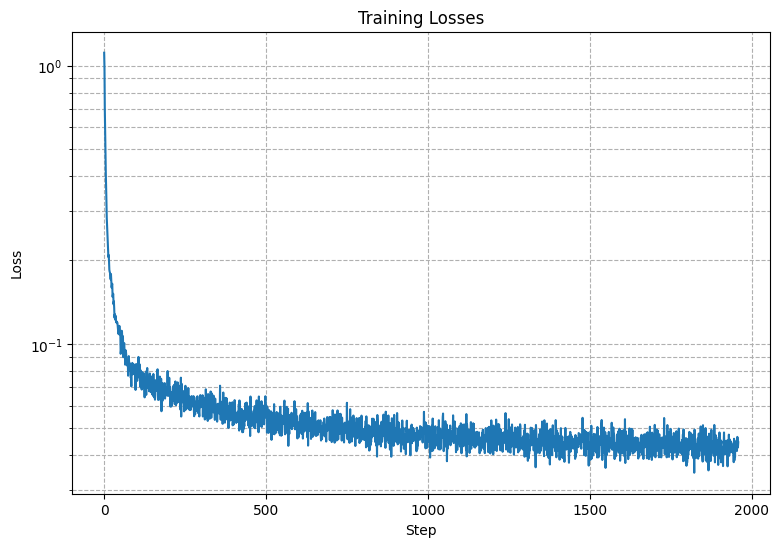

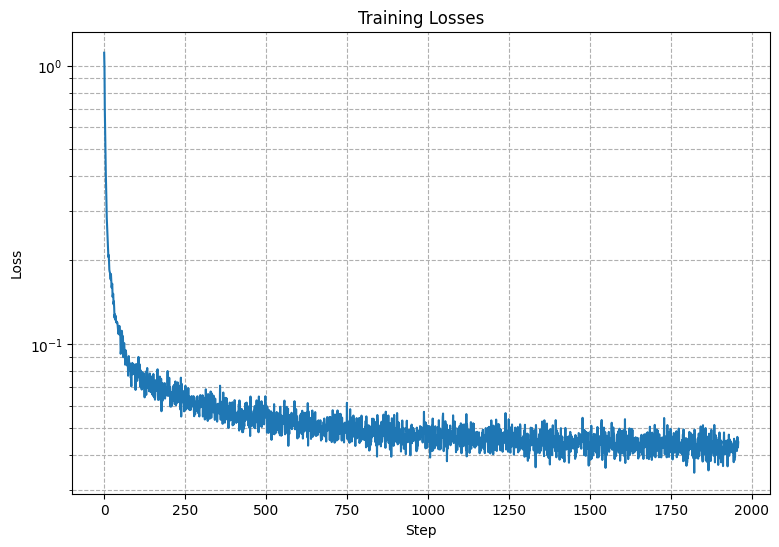

In [28]:
# Plot training loss curves with respect to first 4000 steps
plt.figure(figsize=(9, 6))
plt.semilogy(step_losses[:4000])
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.grid(True, which='both', ls='--')
# Only choose 5 ticks(0, 1000, 2000, 3000, 4000) in the x-axis
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True))
plt.show()


# Plot training loss curves with respect to all steps
plt.figure(figsize=(9, 6))
plt.semilogy(step_losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.grid(True, which='both', ls='--')
plt.show()